In [3]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv.csv to online_retail_II.csv.csv


In [5]:
import pandas as pd

# Data loading
df = pd.read_csv("online_retail_II.csv.csv")

# Ist 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
#How mcuch rows aur columns?
print("Shape:", df.shape)

# Every column's type + missing values
df.info()

Shape: (1048575, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [7]:
# Check how many missing values are in each column
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4372
Quantity,0
InvoiceDate,0
Price,0
Customer ID,236682
Country,0


In [8]:
# Convert InvoiceDate from string (object) to a proper datetime type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Confirm the change — InvoiceDate should now show as datetime64
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1048575 non-null  object        
 1   StockCode    1048575 non-null  object        
 2   Description  1044203 non-null  object        
 3   Quantity     1048575 non-null  int64         
 4   InvoiceDate  1048575 non-null  datetime64[ns]
 5   Price        1048575 non-null  float64       
 6   Customer ID  811893 non-null   float64       
 7   Country      1048575 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 64.0+ MB


In [9]:
# 1. Remove rows with missing Customer ID (can't segment unknown customers)
df = df.dropna(subset=["Customer ID"])

# 2. Remove cancelled orders (Invoice numbers starting with 'C')
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# 3. Keep only real sales: positive quantity AND positive price
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# 4. Customer ID is float due to old missing values — convert to int now
df["Customer ID"] = df["Customer ID"].astype(int)

# 5. Create TotalPrice = Quantity x Price (money spent per row)
df["TotalPrice"] = df["Quantity"] * df["Price"]

# Check the cleaned dataset size
df.shape

(793309, 9)

In [10]:
# Set a "snapshot date" = one day after the last transaction in the data
# (data is from 2009-2011, so we treat the data's end as "today")
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Build the RFM table — one row per customer
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),  # days since last purchase
    Frequency=("Invoice", "nunique"),                                   # number of unique orders
    Monetary=("TotalPrice", "sum")                                      # total money spent
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,321,12,77556.46
1,12347,35,7,5408.50
2,12348,71,5,2019.40
3,12349,14,4,4428.69
4,12350,305,1,334.40


In [11]:
# See the spread (min, max, mean) of each RFM value
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5860.000000,5860.000000,5860.000000,5860.000000
mean,15316.832423,200.982594,6.221331,2956.473053
std,1714.531194,207.490532,12.857032,14352.382490
min,12346.000000,1.000000,1.000000,2.900000
25%,13836.750000,26.000000,1.000000,344.492500
50%,15315.500000,101.000000,3.000000,883.595000
75%,16799.250000,376.000000,7.000000,2284.647500
max,18287.000000,734.000000,391.000000,597336.110000


In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# RFM is very skewed (few customers spend HUGE) — log reduces the skew
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log1p)

# Scale all 3 features to the same range (mean 0, std 1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Ready for KMeans now
print(rfm_scaled[:5])

[[ 0.85480152  1.2671694   3.19746184]
 [-0.59025063  0.66562642  1.27665173]
 [-0.13309914  0.30918905  0.56623904]
 [-1.1676487   0.0832931   1.13250991]
 [ 0.82118761 -1.05198884 -0.72907777]]


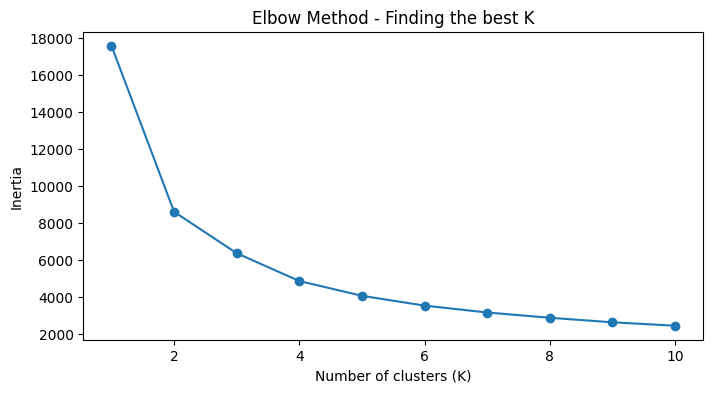

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Try K from 1 to 10 and record inertia (how tight the clusters are)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Finding the best K")
plt.show()

In [14]:
# Fit KMeans with 4 clusters (our elbow point)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign each customer to a cluster (0, 1, 2, or 3)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Profile each cluster: average R, F, M + number of customers
cluster_summary = rfm.groupby("Cluster").agg(
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Customers=("Customer ID", "count")
).round(1)

cluster_summary

,Avg_Recency,Avg_Frequency,Avg_Monetary,Customers
Cluster,,,,
0,396.6,1.4,328.6,1963
1,29.1,2.9,833.2,1267
2,227.0,5.1,2009.8,1452
3,27.8,19.2,10786.0,1178


In [15]:
# Map each cluster number to a business-friendly segment name
segment_names = {
    3: "Champions",
    1: "New / Promising",
    2: "At-Risk",
    0: "Lost / Hibernating"
}
rfm["Segment"] = rfm["Cluster"].map(segment_names)

# How many customers in each segment?
rfm["Segment"].value_counts()

,count
Segment,
Lost / Hibernating,1963
At-Risk,1452
New / Promising,1267
Champions,1178


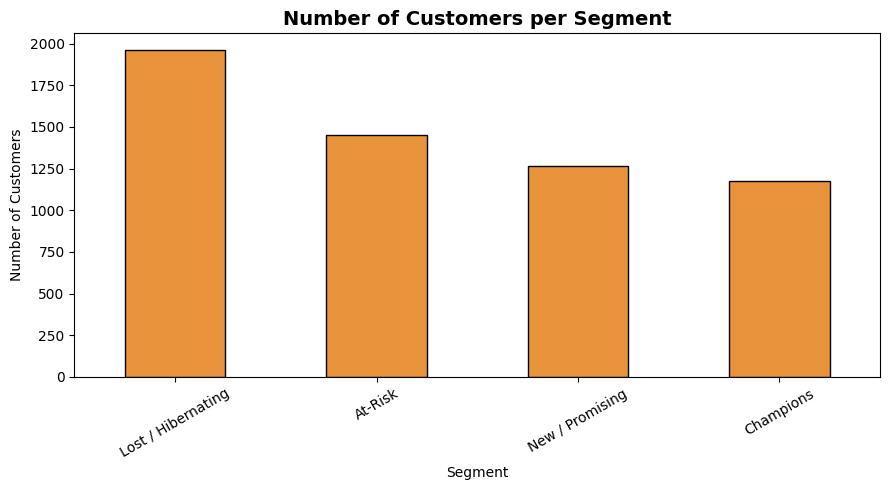

In [16]:
import matplotlib.pyplot as plt

# Count how many customers are in each segment
segment_counts = rfm["Segment"].value_counts()

# Bar chart (using our signature orange!)
plt.figure(figsize=(9, 5))
segment_counts.plot(kind="bar", color="#E8943A", edgecolor="black")
plt.title("Number of Customers per Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

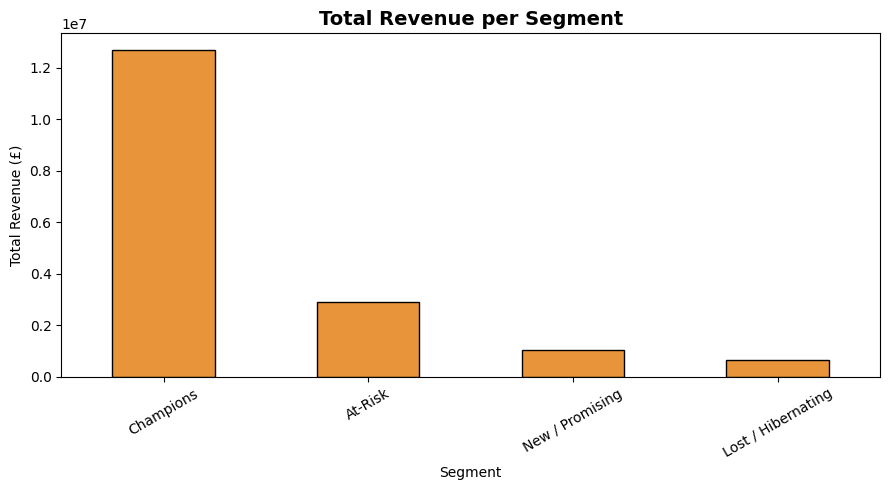

In [17]:
# Total revenue (Monetary) generated by each segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(9, 5))
segment_revenue.plot(kind="bar", color="#E8943A", edgecolor="black")
plt.title("Total Revenue per Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [18]:
# Save the final segmented customers to a CSV
rfm.to_csv("customer_segments.csv", index=False)

# Download it (optional)
from google.colab import files
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Install the lifetimes library
!pip install lifetimes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 23.6 MB/s eta 0:00:00


In [20]:
from lifetimes.utils import summary_data_from_transaction_data

# Build the special summary table these models need
summary = summary_data_from_transaction_data(
    df,
    customer_id_col="Customer ID",
    datetime_col="InvoiceDate",
    monetary_value_col="TotalPrice",
    observation_period_end=df["InvoiceDate"].max()
)

summary.head()

,frequency,recency,T,monetary_value
Customer ID,,,,
12346,7.0,400.0,720.0,11066.637143
12347,6.0,365.0,399.0,799.495000
12348,4.0,363.0,433.0,449.310000
12349,3.0,571.0,584.0,1120.056667
12350,0.0,0.0,305.0,0.000000


In [21]:
from lifetimes import BetaGeoFitter

# Fit the BG/NBD model — it learns each customer's buying & "dropout" pattern
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])

# Predict expected number of purchases in the NEXT 90 days for each customer
summary["predicted_90d"] = bgf.predict(
    90,
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

# Top customers by predicted future purchases
summary.sort_values("predicted_90d", ascending=False).head()

,frequency,recency,T,monetary_value,predicted_90d
Customer ID,,,,,
14911,250.0,730.0,733.0,1155.748120,28.161813
12748,198.0,730.0,730.0,280.925909,22.412709
15311,193.0,731.0,733.0,595.980207,21.761118
17841,190.0,730.0,732.0,360.758789,21.450709
14606,178.0,727.0,731.0,170.170506,20.117654


In [22]:
from lifetimes import GammaGammaFitter

# Gamma-Gamma works only for REPEAT customers (frequency > 0) with positive value
repeat = summary[(summary["frequency"] > 0) & (summary["monetary_value"] > 0)].copy()

# Fit the Gamma-Gamma model — predicts average spend per transaction
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat["frequency"], repeat["monetary_value"])

# Predict each customer's average transaction value
repeat["predicted_avg_value"] = ggf.conditional_expected_average_profit(
    repeat["frequency"],
    repeat["monetary_value"]
)

In [23]:
# Compute CLV for the next 3 months (BG/NBD x Gamma-Gamma)
repeat["CLV"] = ggf.customer_lifetime_value(
    bgf,                    # the BG/NBD model
    repeat["frequency"],
    repeat["recency"],
    repeat["T"],
    repeat["monetary_value"],
    time=3,                 # predict 3 months ahead
    freq="D",               # our recency/T are in Days
    discount_rate=0.01      # monthly discount
)

# Top 10 customers by predicted lifetime value
repeat.sort_values("CLV", ascending=False).head(10)

,frequency,recency,T,monetary_value,predicted_90d,predicted_avg_value,CLV
Customer ID,,,,,,,
18102,64.0,727.0,733.0,9297.654219,7.256826,9299.349534,66157.450289
14646,88.0,721.0,732.0,5808.675682,9.952206,5809.495793,56680.969139
17450,30.0,430.0,433.0,6924.523000,5.498917,6927.316554,37344.452300
14156,120.0,729.0,733.0,2607.329750,13.551495,2607.653397,34643.082407
14911,250.0,730.0,733.0,1155.748120,28.161813,1155.843015,31910.890792
14096,15.0,90.0,96.0,3747.131333,8.565820,3750.513676,31496.653778
12415,22.0,503.0,522.0,6460.528636,3.436127,6464.118845,21775.132940
13694,81.0,710.0,730.0,2355.824198,9.147666,2356.271366,21130.758758
17511,48.0,721.0,732.0,3439.908125,5.461737,3440.897957,18423.920810


In [24]:
# Merge predicted CLV back into the main segment table
rfm = rfm.merge(
    repeat[["CLV", "predicted_avg_value"]],
    left_on="Customer ID",
    right_index=True,
    how="left"
)

# Save the final result (segments + CLV)
rfm.to_csv("customer_segments_clv.csv", index=False)

# Download it
from google.colab import files
files.download("customer_segments_clv.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

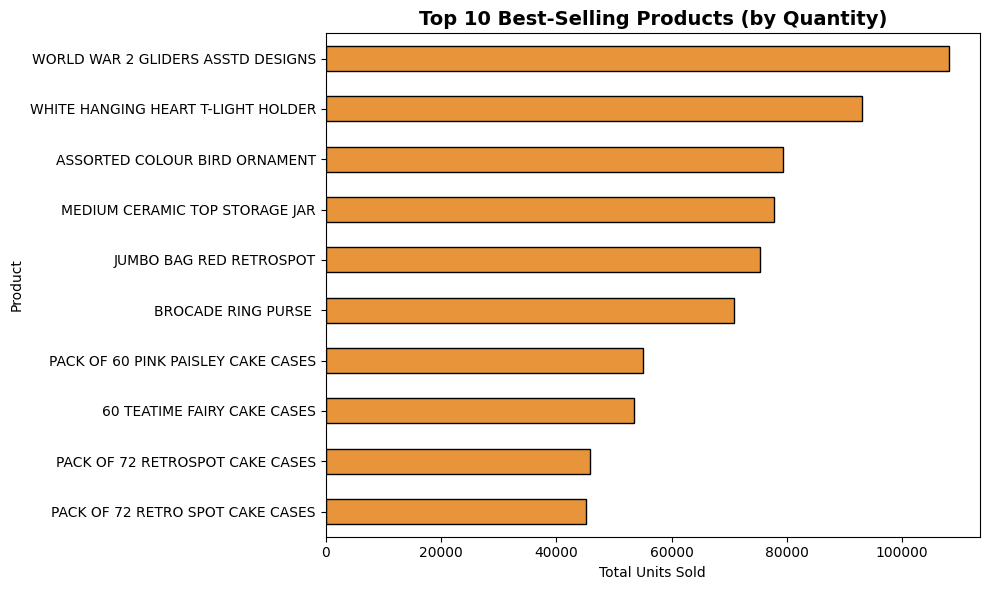

In [25]:
import matplotlib.pyplot as plt

# Top 10 best-selling products by quantity sold
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh", color="#E8943A", edgecolor="black")
plt.title("Top 10 Best-Selling Products (by Quantity)", fontsize=14, fontweight="bold")
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

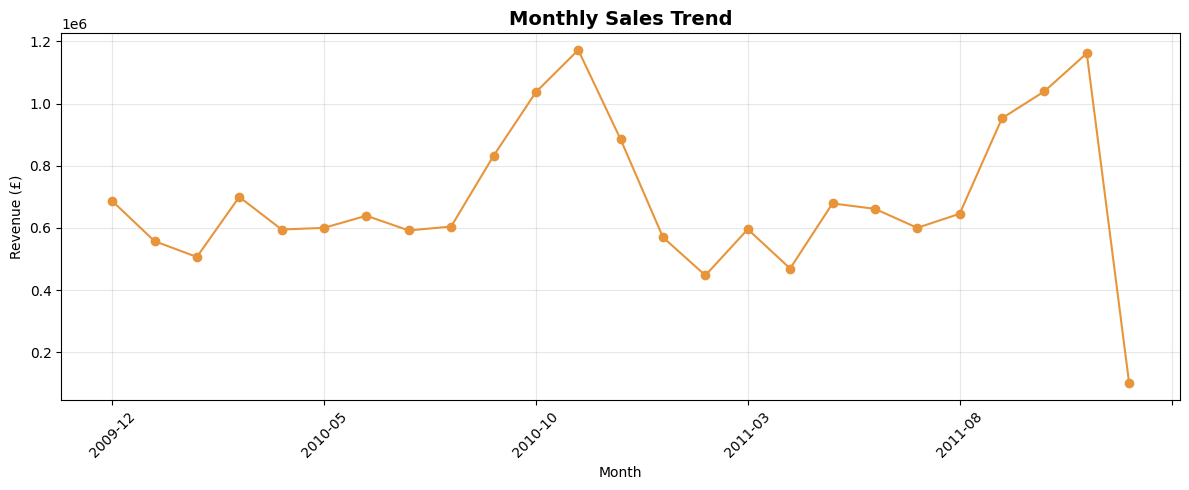

In [26]:
# --- Monthly revenue trend ---
monthly = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"].sum()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(12, 5))
monthly.plot(kind="line", marker="o", color="#E8943A")
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Revenue (£)")
plt.xticks(rotation=45); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

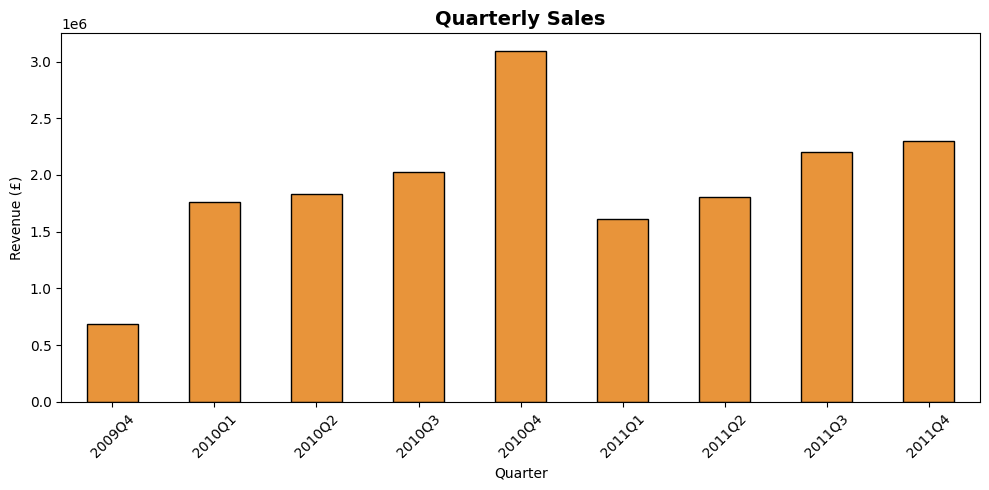

In [27]:
# --- Quarterly sales ---
quarterly = df.groupby(df["InvoiceDate"].dt.to_period("Q"))["TotalPrice"].sum()
quarterly.index = quarterly.index.astype(str)

plt.figure(figsize=(10, 5))
quarterly.plot(kind="bar", color="#E8943A", edgecolor="black")
plt.title("Quarterly Sales", fontsize=14, fontweight="bold")
plt.xlabel("Quarter"); plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

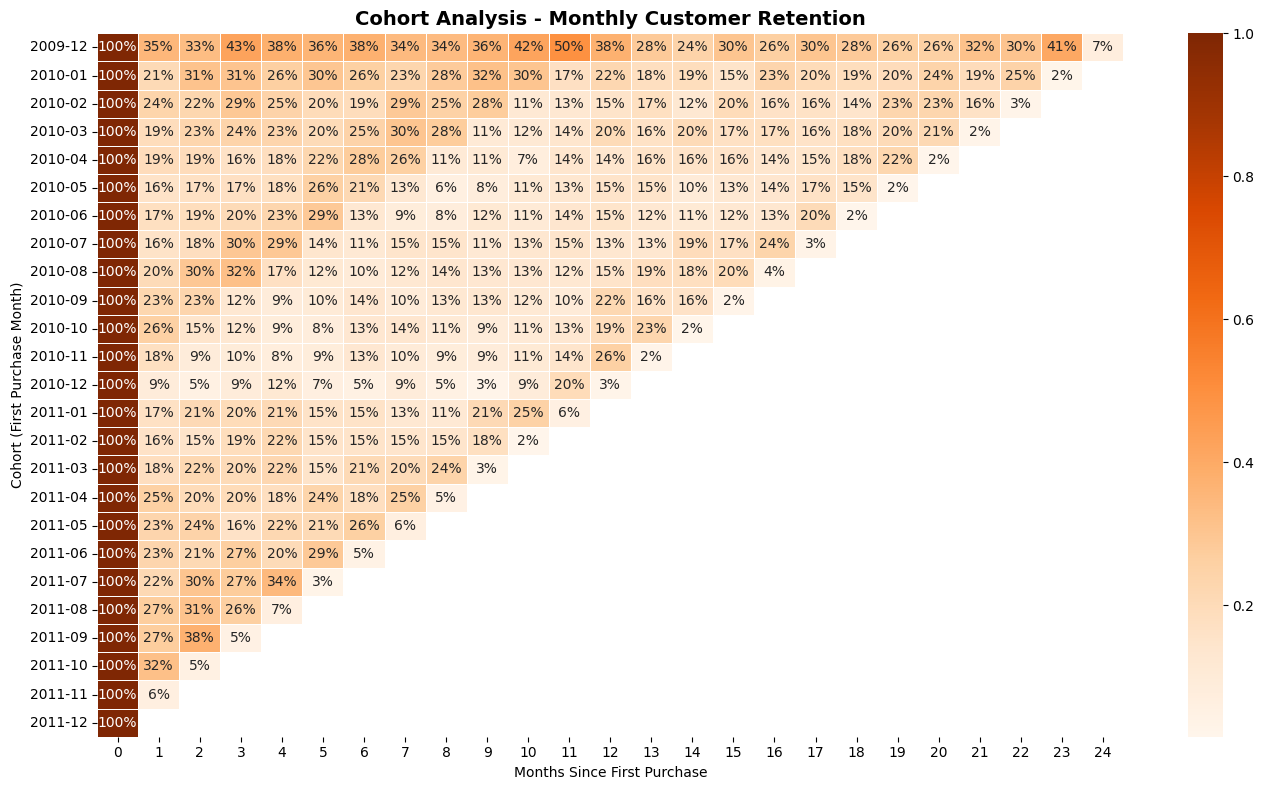

In [28]:
import seaborn as sns

# Work on a copy
dfc = df.copy()

# 1. Each transaction's month
dfc["InvoiceMonth"] = dfc["InvoiceDate"].dt.to_period("M")

# 2. Each customer's FIRST purchase month (their cohort)
dfc["CohortMonth"] = dfc.groupby("Customer ID")["InvoiceMonth"].transform("min")

# 3. How many months after joining is this purchase?
dfc["CohortIndex"] = (dfc["InvoiceMonth"] - dfc["CohortMonth"]).apply(lambda x: x.n)

# 4. Count unique customers per cohort, per month-offset
cohort = dfc.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().reset_index()

# 5. Pivot into a cohort table
pivot = cohort.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")

# 6. Retention rate = each value / the cohort's starting size
retention = pivot.divide(pivot.iloc[:, 0], axis=0)

# 7. Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Oranges", linewidths=0.5)
plt.title("Cohort Analysis - Monthly Customer Retention", fontsize=14, fontweight="bold")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")
plt.tight_layout()
plt.show()